# This scripts merge vmPFC coverage stats to MRIQC group files. It also loops through fmriprep individual confound files to compute additional QC metrics. This leads to figure s1 eventually. 

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df_coverage = pd.read_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/coverage_all_vmpfc.csv')
df_mriqc = pd.read_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/group_bold.tsv', sep='\t')

In [34]:
print("df_coverage columns:", df_coverage.columns.tolist())
print("df_mriqc columns:", df_mriqc.columns.tolist())

print("Unique values in df_coverage['Method']:", df_coverage['Method'].unique())

print("\ndf_coverage statistics:")
print(df_coverage.describe(include='all'))

print("\ndf_mriqc statistics:")
print(df_mriqc.describe(include='all'))

df_coverage columns: ['Method', 'Subject', 'Session', 'Run', 'Total_vmPFC_voxels', 'Covered_voxels', 'Uncovered_voxels', 'Coverage_percentage']
df_mriqc columns: ['bids_name', 'aor', 'aqi', 'dummy_trs', 'dvars_nstd', 'dvars_std', 'dvars_vstd', 'efc', 'fber', 'fd_mean', 'fd_num', 'fd_perc', 'fwhm_avg', 'fwhm_x', 'fwhm_y', 'fwhm_z', 'gcor', 'gsr_x', 'gsr_y', 'size_t', 'size_x', 'size_y', 'size_z', 'snr', 'spacing_tr', 'spacing_x', 'spacing_y', 'spacing_z', 'summary_bg_k', 'summary_bg_mad', 'summary_bg_mean', 'summary_bg_median', 'summary_bg_n', 'summary_bg_p05', 'summary_bg_p95', 'summary_bg_stdv', 'summary_fg_k', 'summary_fg_mad', 'summary_fg_mean', 'summary_fg_median', 'summary_fg_n', 'summary_fg_p05', 'summary_fg_p95', 'summary_fg_stdv', 'tsnr']
Unique values in df_coverage['Method']: ['fmap_SDC_23.106' 'fmap_SDC_23.107' 'fmap_SDC_23.109' ...
 'fmap_SDC_25.969' 'fmap_SDC_25.970' 'fmap_SDC_25.976']

df_coverage statistics:
                 Method     Subject Session    Run  Total_vmPFC

In [35]:
df_coverage_fmap25 = df_coverage[df_coverage['Method'].str.contains('fmap_SDC_25')]

print(df_coverage_fmap25.describe(include='all'))
print(df_mriqc.describe(include='all'))

                 Method     Subject Session    Run  Total_vmPFC_voxels  \
count               980         980     980    980               980.0   
unique              980          99       6      3                 NaN   
top     fmap_SDC_25.106  sub-RND022   ses-1  run-1                 NaN   
freq                  1          15     280    329                 NaN   
mean                NaN         NaN     NaN    NaN               168.0   
std                 NaN         NaN     NaN    NaN                 0.0   
min                 NaN         NaN     NaN    NaN               168.0   
25%                 NaN         NaN     NaN    NaN               168.0   
50%                 NaN         NaN     NaN    NaN               168.0   
75%                 NaN         NaN     NaN    NaN               168.0   
max                 NaN         NaN     NaN    NaN               168.0   

        Covered_voxels  Uncovered_voxels  Coverage_percentage  
count       980.000000        980.000000       

In [36]:
# Create a new column in df_coverage_fmap25 to match the BIDS structure in df_mriqc['bids_name']
df_coverage_fmap25['bids_name'] = (
    df_coverage_fmap25['Subject'] + '_' +
    df_coverage_fmap25['Session'] + '_task-BDM_' +
    df_coverage_fmap25['Run'] + '_bold'
)

# Reorder columns to have 'bids_name' as the last column (optional)
cols = [col for col in df_coverage_fmap25.columns if col != 'bids_name'] + ['bids_name']
df_coverage_fmap25 = df_coverage_fmap25[cols]

print("df_coverage_fmap25['bids_name'] head 20:")
print(df_coverage_fmap25['bids_name'].head(20))

df_coverage_fmap25['bids_name'] head 20:
7     sub-RCX203_ses-1_task-BDM_run-1_bold
8     sub-RCX203_ses-1_task-BDM_run-2_bold
9     sub-RCX203_ses-1_task-BDM_run-3_bold
10    sub-RCX203_ses-2_task-BDM_run-1_bold
11    sub-RCX203_ses-2_task-BDM_run-2_bold
12    sub-RCX203_ses-2_task-BDM_run-3_bold
13    sub-RCX203_ses-3_task-BDM_run-1_bold
14    sub-RCX203_ses-3_task-BDM_run-2_bold
15    sub-RCX203_ses-3_task-BDM_run-3_bold
16    sub-RCX203_ses-4_task-BDM_run-1_bold
17    sub-RCX203_ses-4_task-BDM_run-2_bold
18    sub-RCX203_ses-4_task-BDM_run-3_bold
19    sub-RND042_ses-2_task-BDM_run-1_bold
29    sub-RND057_ses-3_task-BDM_run-3_bold
40    sub-RND057_ses-3_task-BDM_run-1_bold
53    sub-RND002_ses-4_task-BDM_run-3_bold
62    sub-RND002_ses-4_task-BDM_run-1_bold
63    sub-RND002_ses-4_task-BDM_run-2_bold
67    sub-RND002_ses-3_task-BDM_run-1_bold
70    sub-RND057_ses-2_task-BDM_run-2_bold
Name: bids_name, dtype: object


C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\1401691820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_coverage_fmap25['bids_name'] = (


In [37]:
print("df_coverage_fmap25['Subject'] head 20:")
print(df_coverage_fmap25['Subject'].head(20))

print("\ndf_mriqc['bids_name'] head 20:")
print(df_mriqc['bids_name'].head(20))

df_coverage_fmap25['Subject'] head 20:
7     sub-RCX203
8     sub-RCX203
9     sub-RCX203
10    sub-RCX203
11    sub-RCX203
12    sub-RCX203
13    sub-RCX203
14    sub-RCX203
15    sub-RCX203
16    sub-RCX203
17    sub-RCX203
18    sub-RCX203
19    sub-RND042
29    sub-RND057
40    sub-RND057
53    sub-RND002
62    sub-RND002
63    sub-RND002
67    sub-RND002
70    sub-RND057
Name: Subject, dtype: object

df_mriqc['bids_name'] head 20:
0     sub-RCX096_ses-2_task-BDM_run-1_bold
1     sub-RCX096_ses-2_task-BDM_run-2_bold
2     sub-RCX096_ses-2_task-BDM_run-3_bold
3     sub-RCX096_ses-3_task-BDM_run-1_bold
4     sub-RCX096_ses-3_task-BDM_run-2_bold
5     sub-RCX096_ses-3_task-BDM_run-3_bold
6     sub-RCX096_ses-4_task-BDM_run-1_bold
7     sub-RCX096_ses-4_task-BDM_run-2_bold
8     sub-RCX096_ses-4_task-BDM_run-3_bold
9     sub-RCX097_ses-1_task-BDM_run-1_bold
10    sub-RCX097_ses-1_task-BDM_run-2_bold
11    sub-RCX097_ses-1_task-BDM_run-3_bold
12    sub-RCX097_ses-2_task-BDM_run-1_bold
1

In [38]:
cols = ['Method', 'Subject', 'Session', 'Run', 'Total_vmPFC_voxels', 'Covered_voxels', 'Uncovered_voxels', 'Coverage_percentage', 'bids_name']
df_coverage_fmap25 = df_coverage_fmap25[cols]

print("df_coverage_fmap25['bids_name'] head 20:")
print(df_coverage_fmap25['bids_name'].head(20))

print("\ndf_mriqc['bids_name'] head 20:")
print(df_mriqc['bids_name'].head(20))


df_coverage_fmap25['bids_name'] head 20:
7     sub-RCX203_ses-1_task-BDM_run-1_bold
8     sub-RCX203_ses-1_task-BDM_run-2_bold
9     sub-RCX203_ses-1_task-BDM_run-3_bold
10    sub-RCX203_ses-2_task-BDM_run-1_bold
11    sub-RCX203_ses-2_task-BDM_run-2_bold
12    sub-RCX203_ses-2_task-BDM_run-3_bold
13    sub-RCX203_ses-3_task-BDM_run-1_bold
14    sub-RCX203_ses-3_task-BDM_run-2_bold
15    sub-RCX203_ses-3_task-BDM_run-3_bold
16    sub-RCX203_ses-4_task-BDM_run-1_bold
17    sub-RCX203_ses-4_task-BDM_run-2_bold
18    sub-RCX203_ses-4_task-BDM_run-3_bold
19    sub-RND042_ses-2_task-BDM_run-1_bold
29    sub-RND057_ses-3_task-BDM_run-3_bold
40    sub-RND057_ses-3_task-BDM_run-1_bold
53    sub-RND002_ses-4_task-BDM_run-3_bold
62    sub-RND002_ses-4_task-BDM_run-1_bold
63    sub-RND002_ses-4_task-BDM_run-2_bold
67    sub-RND002_ses-3_task-BDM_run-1_bold
70    sub-RND057_ses-2_task-BDM_run-2_bold
Name: bids_name, dtype: object

df_mriqc['bids_name'] head 20:
0     sub-RCX096_ses-2_task-BDM_run-

In [39]:
# Merge the 'Coverage_percentage' column from df_coverage to df_mriqc using 'bids_name'
df_mriqc = df_mriqc.merge(
    df_coverage_fmap25[['bids_name', 'Coverage_percentage']],
    on='bids_name',
    how='left'
)

print(df_mriqc[['bids_name', 'Coverage_percentage']].head())



                              bids_name  Coverage_percentage
0  sub-RCX096_ses-2_task-BDM_run-1_bold                100.0
1  sub-RCX096_ses-2_task-BDM_run-2_bold                100.0
2  sub-RCX096_ses-2_task-BDM_run-3_bold                100.0
3  sub-RCX096_ses-3_task-BDM_run-1_bold                100.0
4  sub-RCX096_ses-3_task-BDM_run-2_bold                100.0


In [40]:
# No need to rename or drop columns, just save the merged DataFrame
# (Coverage_percentage is already present after merge)

print(df_mriqc.describe(include='all'))

                                   bids_name         aor         aqi  \
count                                    971  971.000000  971.000000   
unique                                   971         NaN         NaN   
top     sub-RCX096_ses-2_task-BDM_run-1_bold         NaN         NaN   
freq                                       1         NaN         NaN   
mean                                     NaN    0.014447    0.023565   
std                                      NaN    0.018923    0.031669   
min                                      NaN    0.001146    0.002872   
25%                                      NaN    0.003902    0.008312   
50%                                      NaN    0.008291    0.012471   
75%                                      NaN    0.015871    0.022215   
max                                      NaN    0.135164    0.282735   

         dummy_trs  dvars_nstd   dvars_std  dvars_vstd         efc  \
count   971.000000  971.000000  971.000000  971.000000  971.00000

In [41]:
import os

confounds_dir = '/home/gagpat01/mes_projets/maitrise/fmri/derivatives/confounds'
confound_files = [f for f in os.listdir(confounds_dir) if f.endswith('.tsv')]

if confound_files:
    confound_path = os.path.join(confounds_dir, confound_files[0])
    df_sample_conf = pd.read_csv(confound_path, sep='\t')
    print(df_sample_conf.head())
else:
    print("No confound files found.")


   global_signal  global_signal_derivative1  global_signal_power2  \
0   16915.520296                        NaN          2.861348e+08   
1   16985.805831                  70.285535          2.885176e+08   
2   16936.093450                 -49.712381          2.868313e+08   
3   16832.931156                -103.162294          2.833476e+08   
4   16789.459364                 -43.471792          2.818859e+08   

   global_signal_derivative1_power2           csf  csf_derivative1  \
0                               NaN  27092.714756              NaN   
1                       4940.056487  27152.517911        59.803155   
2                       2471.320866  27128.471547       -24.046364   
3                      10642.458890  27095.019926       -33.451621   
4                       1889.796666  26838.057123      -256.962804   

     csf_power2  csf_derivative1_power2  white_matter  \
0  7.340152e+08                     NaN  16593.477684   
1  7.372592e+08             3576.417397  16650.261

In [42]:
# Extract the max value of framewise_displacement
max_fd = df_sample_conf['framewise_displacement'].max()

# Count how many times framewise_displacement is over 3mm
num_fd_over_3mm = (df_sample_conf['framewise_displacement'] > 3).sum()

print(f"Max framewise_displacement: {max_fd}")
print(f"Number of timepoints with framewise_displacement > 3mm: {num_fd_over_3mm}")

Max framewise_displacement: 1.8923145470105536
Number of timepoints with framewise_displacement > 3mm: 0


In [43]:
confounds_dir
confound_files = [f for f in os.listdir(confounds_dir) if f.endswith('.tsv')]

confound_summary = []

for fname in confound_files:
    confound_path = os.path.join(confounds_dir, fname)
    try:
        df_conf = pd.read_csv(confound_path, sep='\t')
        max_fd = df_conf['framewise_displacement'].max()
        num_fd_over_3mm = (df_conf['framewise_displacement'] > 3).sum()
        # Convert confound file name to match bids_name in df_mriqc
        bids_name = fname.replace('_desc-confounds_timeseries.tsv', '_bold')
        confound_summary.append({
            'bids_name': bids_name,
            'fd_max': max_fd,
            'fd_num_above_3mm': num_fd_over_3mm
        })
    except Exception as e:
        print(f"Error processing {fname}: {e}")

confound_df = pd.DataFrame(confound_summary)

if not confound_df.empty:
    df_mriqc = df_mriqc.merge(confound_df, on='bids_name', how='left')
else:
    print("No confound summary to merge.")

print(df_mriqc[['bids_name', 'fd_max', 'fd_num_above_3mm']].head())

                              bids_name    fd_max  fd_num_above_3mm
0  sub-RCX096_ses-2_task-BDM_run-1_bold  2.270573               0.0
1  sub-RCX096_ses-2_task-BDM_run-2_bold  1.345536               0.0
2  sub-RCX096_ses-2_task-BDM_run-3_bold  1.702802               0.0
3  sub-RCX096_ses-3_task-BDM_run-1_bold  3.366496               7.0
4  sub-RCX096_ses-3_task-BDM_run-2_bold  4.765208               9.0


In [44]:
# Z-score every column in df_mriqc except 'bids_name' and 'Session', grouped by session
# First, extract 'Session' from 'bids_name' (format: sub-XXX_ses-Y_task-..._run-Z_bold)
df_mriqc['Session'] = df_mriqc['bids_name'].str.extract(r'ses-([a-zA-Z0-9]+)')

# Verify Session is categorical/string
print(f"Session dtype: {df_mriqc['Session'].dtype}")
print(f"Unique sessions: {sorted(df_mriqc['Session'].unique())}")
print(f"Session counts:\n{df_mriqc['Session'].value_counts().sort_index()}")


# Identify columns to z-score (exclude 'bids_name' and 'Session')
cols_to_zscore = [col for col in df_mriqc.columns if col not in ['bids_name', 'Session'] and df_mriqc[col].dtype != 'O']

# Z-score per session and add new columns
for col in cols_to_zscore:
    z_col = f'{col}_zscore'
    df_mriqc[z_col] = df_mriqc.groupby('Session')[col].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

    print(f"Stats for {z_col}:")
    print(df_mriqc[z_col].describe())

Session dtype: object
Unique sessions: ['1', '2', '3', '4', '5', 'x']
Session counts:
Session
1    277
2    252
3    181
4    180
5     24
x     57
Name: count, dtype: int64
Stats for aor_zscore:
count    9.710000e+02
mean    -2.195292e-17
std      1.000515e+00
min     -1.321627e+00
25%     -5.607264e-01
50%     -3.382661e-01
75%      9.303087e-02
max      6.010372e+00
Name: aor_zscore, dtype: float64
Stats for aqi_zscore:
count    9.710000e+02
mean    -7.317639e-18
std      1.000515e+00
min     -1.071735e+00
25%     -4.898801e-01
50%     -3.522837e-01
75%     -1.713015e-02
max      6.867760e+00
Name: aqi_zscore, dtype: float64
Stats for dummy_trs_zscore:
count    9.470000e+02
mean     1.500618e-17
std      1.000528e+00
min     -3.992713e-01
25%     -2.962709e-01
50%     -2.928413e-01
75%     -2.742902e-01
max      7.405835e+00
Name: dummy_trs_zscore, dtype: float64
Stats for dvars_nstd_zscore:
count    9.710000e+02
mean     2.195292e-17
std      1.000515e+00
min     -1.697602e+00
25% 

In [45]:
# Move each z-score column to be immediately after its corresponding original column
cols = list(df_mriqc.columns)
zscore_cols = [col for col in cols if col.endswith('_zscore')]

for z_col in zscore_cols:
    orig_col = z_col[:-7]  # remove '_zscore'
    if orig_col in cols:
        # Remove z_col from its current position
        cols.remove(z_col)
        # Insert z_col right after orig_col
        orig_idx = cols.index(orig_col)
        cols.insert(orig_idx + 1, z_col)

df_mriqc = df_mriqc[cols]

In [46]:
df_mriqc.describe(include='all')

,bids_name,aor,aor_zscore,aqi,aqi_zscore,dummy_trs,dummy_trs_zscore,dvars_nstd,dvars_nstd_zscore,dvars_std,...,summary_fg_stdv_zscore,tsnr,tsnr_zscore,Coverage_percentage,Coverage_percentage_zscore,fd_max,fd_max_zscore,fd_num_above_3mm,fd_num_above_3mm_zscore,Session
count,971,971.000000,9.710000e+02,971.000000,9.710000e+02,971.000000,9.470000e+02,971.000000,9.710000e+02,971.000000,...,9.710000e+02,971.000000,9.710000e+02,971.000000,9.710000e+02,969.000000,9.690000e+02,969.000000,9.690000e+02,971
unique,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,sub-RCX096_ses-2_task-BDM_run-1_bold,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,277
mean,NaN,0.014447,-2.195292e-17,0.023565,-7.317639e-18,0.353244,1.500618e-17,37.445698,2.195292e-17,1.262036,...,2.341644e-16,47.030757,-5.122347e-17,97.380463,5.195524e-16,2.225075,1.649867e-17,1.906089,-3.299734e-17,NaN
std,NaN,0.018923,1.000515e+00,0.031669,1.000515e+00,1.148660,1.000528e+00,15.306741,1.000515e+00,0.175478,...,1.000515e+00,16.640879,1.000515e+00,11.715926,1.000515e+00,2.608865,1.000516e+00,6.721009,1.000516e+00,NaN
min,NaN,0.001146,-1.321627e+00,0.002872,-1.071735e+00,0.000000,-3.992713e-01,14.771479,-1.697602e+00,0.544432,...,-2.926752e+00,5.953677,-2.396070e+00,0.000000,-9.354492e+00,0.130232,-9.771686e-01,0.000000,-5.336119e-01,NaN
25%,NaN,0.003902,-5.607264e-01,0.008312,-4.898801e-01,0.000000,-2.962709e-01,28.567703,-5.660232e-01,1.177390,...,-5.620210e-01,35.158385,-6.954553e-01,99.400000,1.604627e-01,0.788024,-5.904141e-01,0.000000,-2.806769e-01,NaN
50%,NaN,0.008291,-3.382661e-01,0.012471,-3.522837e-01,0.000000,-2.928413e-01,33.593747,-2.227051e-01,1.262108,...,6.998498e-02,47.952205,3.582422e-02,100.000000,1.829971e-01,1.434423,-3.299560e-01,0.000000,-2.805639e-01,NaN
75%,NaN,0.015871,9.303087e-02,0.022215,-1.713015e-02,0.000000,-2.742902e-01,41.514252,2.635090e-01,1.352941,...,5.476088e-01,58.763507,7.097254e-01,100.000000,2.714391e-01,2.857182,2.436826e-01,0.000000,-2.085144e-01,NaN


C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


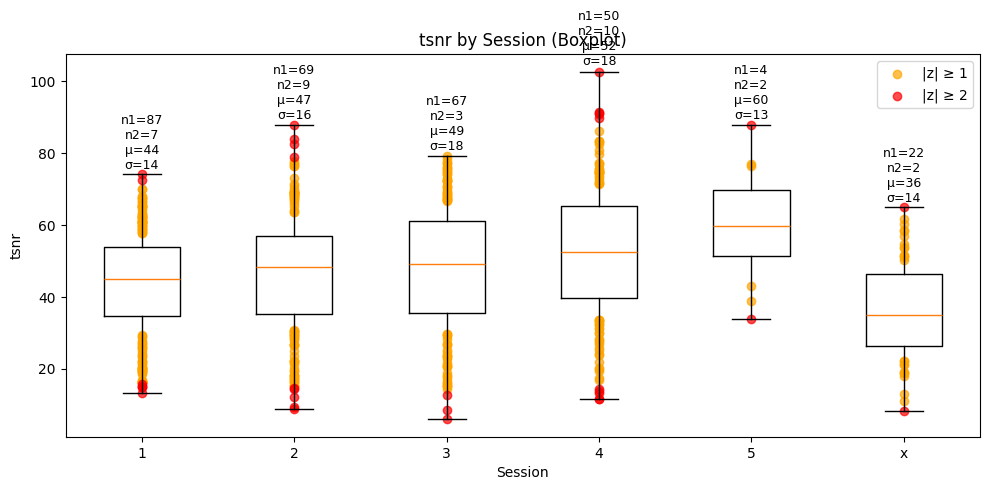

Union of outliers (|tsnr_zscore| >= 1): ['sub-RCX096_ses-3_task-BDM_run-1_bold', 'sub-RCX096_ses-3_task-BDM_run-2_bold', 'sub-RCX097_ses-2_task-BDM_run-1_bold', 'sub-RCX097_ses-2_task-BDM_run-2_bold', 'sub-RCX097_ses-2_task-BDM_run-3_bold', 'sub-RCX136_ses-4_task-BDM_run-1_bold', 'sub-RCX136_ses-4_task-BDM_run-2_bold', 'sub-RCX146_ses-1_task-BDM_run-3_bold', 'sub-RCX146_ses-3_task-BDM_run-1_bold', 'sub-RCX146_ses-3_task-BDM_run-2_bold', 'sub-RCX146_ses-3_task-BDM_run-3_bold', 'sub-RCX146_ses-4_task-BDM_run-2_bold', 'sub-RCX146_ses-4_task-BDM_run-3_bold', 'sub-RCX147_ses-2_task-BDM_run-1_bold', 'sub-RCX164_ses-1_task-BDM_run-1_bold', 'sub-RCX164_ses-1_task-BDM_run-2_bold', 'sub-RCX164_ses-2_task-BDM_run-1_bold', 'sub-RCX164_ses-2_task-BDM_run-2_bold', 'sub-RCX164_ses-3_task-BDM_run-1_bold', 'sub-RCX164_ses-3_task-BDM_run-2_bold', 'sub-RCX164_ses-4_task-BDM_run-2_bold', 'sub-RCX164_ses-5_task-BDM_run-3_bold', 'sub-RCX191_ses-2_task-BDM_run-2_bold', 'sub-RCX200_ses-1_task-BDM_run-3_bold',

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


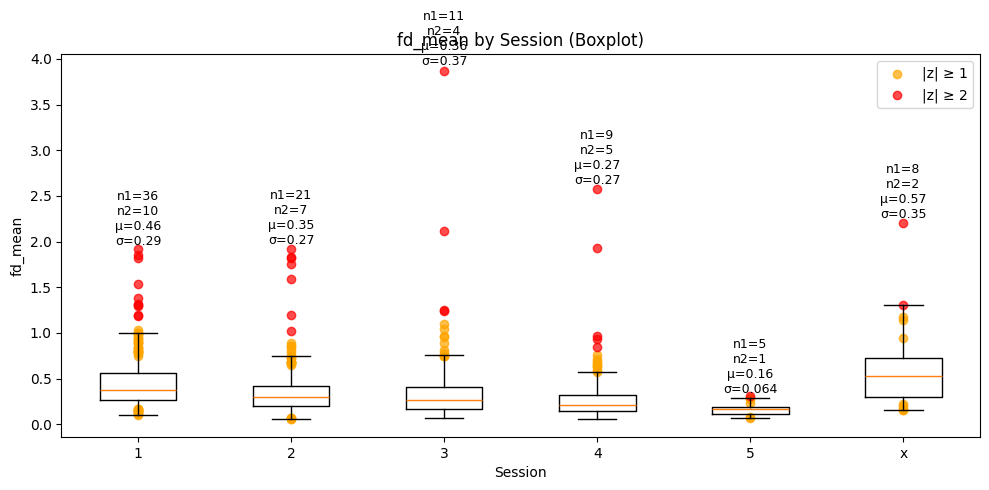

Union of outliers (|fd_mean_zscore| >= 1): ['sub-RCX146_ses-3_task-BDM_run-1_bold', 'sub-RCX146_ses-3_task-BDM_run-2_bold', 'sub-RCX147_ses-2_task-BDM_run-1_bold', 'sub-RCX148_ses-1_task-BDM_run-3_bold', 'sub-RCX164_ses-4_task-BDM_run-2_bold', 'sub-RCX211_ses-1_task-BDM_run-3_bold', 'sub-RCX247_ses-1_task-BDM_run-2_bold', 'sub-RCX247_ses-1_task-BDM_run-3_bold', 'sub-RGC901_ses-1_task-BDM_run-3_bold', 'sub-RGC901_ses-x_task-BDM_run-1_bold', 'sub-RGC901_ses-x_task-BDM_run-3_bold', 'sub-RGC903_ses-2_task-BDM_run-1_bold', 'sub-RGC904_ses-1_task-BDM_run-2_bold', 'sub-RGC904_ses-2_task-BDM_run-3_bold', 'sub-RGC904_ses-x_task-BDM_run-3_bold', 'sub-RGC910_ses-2_task-BDM_run-3_bold', 'sub-RGC912_ses-2_task-BDM_run-1_bold', 'sub-RGC912_ses-x_task-BDM_run-3_bold', 'sub-RGC913_ses-1_task-BDM_run-3_bold', 'sub-RGC916_ses-2_task-BDM_run-1_bold', 'sub-RGC916_ses-2_task-BDM_run-2_bold', 'sub-RGC916_ses-2_task-BDM_run-3_bold', 'sub-RGC916_ses-x_task-BDM_run-3_bold', 'sub-RGC917_ses-1_task-BDM_run-1_bol

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


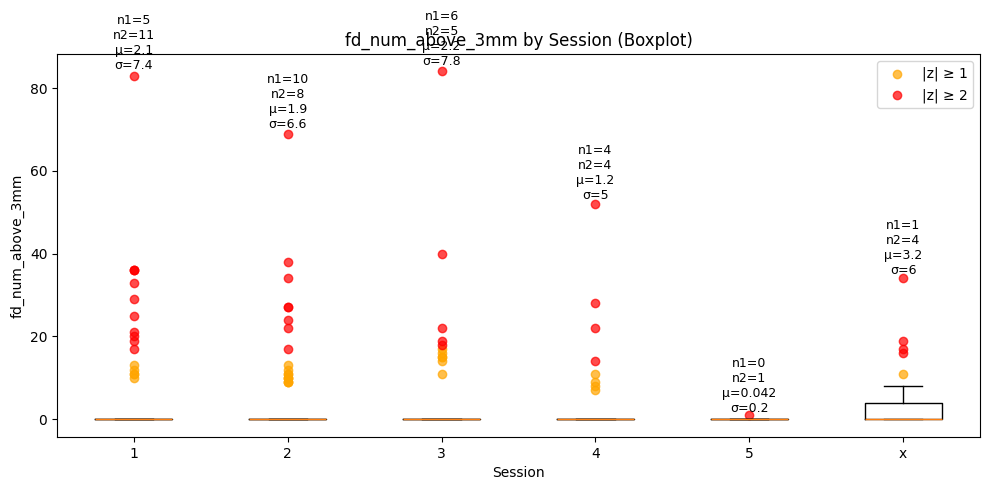

Union of outliers (|fd_num_above_3mm_zscore| >= 1): ['sub-RCX146_ses-3_task-BDM_run-2_bold', 'sub-RCX147_ses-2_task-BDM_run-1_bold', 'sub-RCX164_ses-4_task-BDM_run-2_bold', 'sub-RCX200_ses-1_task-BDM_run-3_bold', 'sub-RGC903_ses-2_task-BDM_run-1_bold', 'sub-RGC903_ses-2_task-BDM_run-3_bold', 'sub-RGC903_ses-x_task-BDM_run-2_bold', 'sub-RGC904_ses-1_task-BDM_run-2_bold', 'sub-RGC904_ses-1_task-BDM_run-3_bold', 'sub-RGC904_ses-x_task-BDM_run-3_bold', 'sub-RGC907_ses-x_task-BDM_run-2_bold', 'sub-RGC910_ses-2_task-BDM_run-3_bold', 'sub-RGC913_ses-1_task-BDM_run-3_bold', 'sub-RGC916_ses-2_task-BDM_run-2_bold', 'sub-RGC916_ses-2_task-BDM_run-3_bold', 'sub-RGC916_ses-x_task-BDM_run-2_bold', 'sub-RGC916_ses-x_task-BDM_run-3_bold', 'sub-RGC921_ses-2_task-BDM_run-1_bold', 'sub-RND005_ses-4_task-BDM_run-1_bold', 'sub-RND005_ses-4_task-BDM_run-2_bold', 'sub-RND005_ses-4_task-BDM_run-3_bold', 'sub-RND010_ses-4_task-BDM_run-1_bold', 'sub-RND011_ses-3_task-BDM_run-2_bold', 'sub-RND011_ses-3_task-BDM_

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


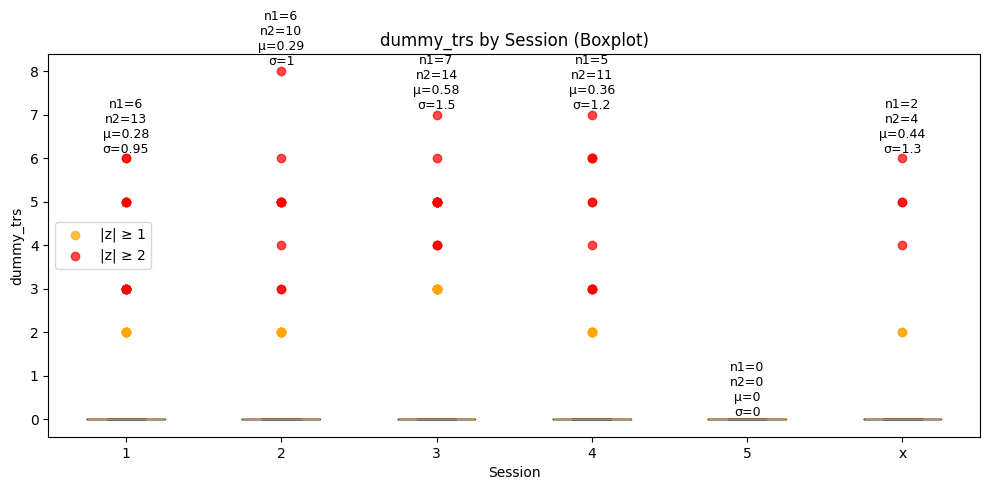

Union of outliers (|dummy_trs_zscore| >= 1): ['sub-RCX096_ses-3_task-BDM_run-2_bold', 'sub-RCX096_ses-4_task-BDM_run-2_bold', 'sub-RCX097_ses-3_task-BDM_run-3_bold', 'sub-RCX097_ses-4_task-BDM_run-2_bold', 'sub-RCX097_ses-4_task-BDM_run-3_bold', 'sub-RCX126_ses-1_task-BDM_run-3_bold', 'sub-RCX126_ses-3_task-BDM_run-2_bold', 'sub-RCX126_ses-4_task-BDM_run-2_bold', 'sub-RCX136_ses-2_task-BDM_run-3_bold', 'sub-RCX136_ses-3_task-BDM_run-3_bold', 'sub-RCX148_ses-3_task-BDM_run-3_bold', 'sub-RCX148_ses-4_task-BDM_run-1_bold', 'sub-RCX148_ses-4_task-BDM_run-3_bold', 'sub-RCX200_ses-1_task-BDM_run-2_bold', 'sub-RCX200_ses-4_task-BDM_run-3_bold', 'sub-RCX203_ses-2_task-BDM_run-3_bold', 'sub-RCX203_ses-3_task-BDM_run-2_bold', 'sub-RCX203_ses-3_task-BDM_run-3_bold', 'sub-RCX203_ses-4_task-BDM_run-2_bold', 'sub-RCX247_ses-1_task-BDM_run-2_bold', 'sub-RGC901_ses-2_task-BDM_run-2_bold', 'sub-RGC903_ses-2_task-BDM_run-1_bold', 'sub-RGC904_ses-x_task-BDM_run-2_bold', 'sub-RGC905_ses-2_task-BDM_run-2_b

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


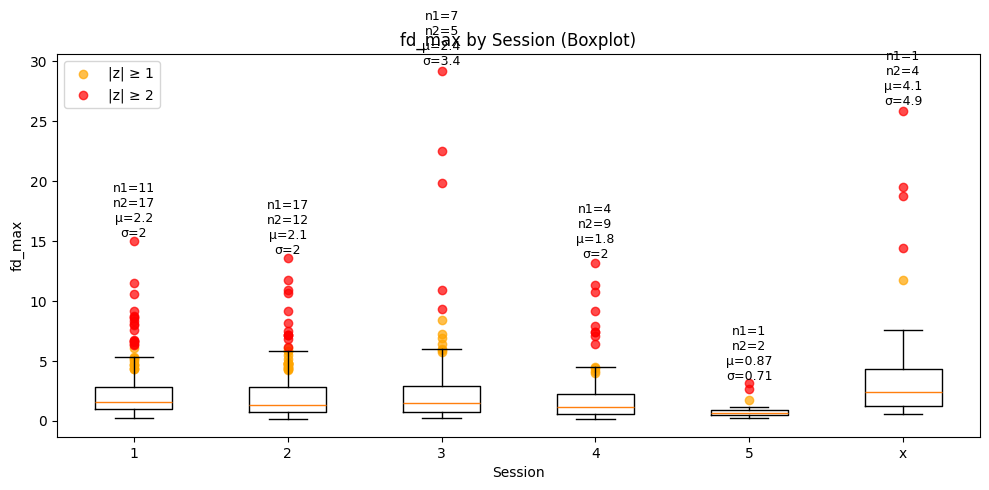

Union of outliers (|fd_max_zscore| >= 1): ['sub-RCX146_ses-1_task-BDM_run-3_bold', 'sub-RCX146_ses-3_task-BDM_run-2_bold', 'sub-RCX146_ses-4_task-BDM_run-3_bold', 'sub-RCX147_ses-1_task-BDM_run-3_bold', 'sub-RGC903_ses-2_task-BDM_run-3_bold', 'sub-RGC904_ses-x_task-BDM_run-3_bold', 'sub-RGC906_ses-1_task-BDM_run-3_bold', 'sub-RGC910_ses-1_task-BDM_run-2_bold', 'sub-RGC910_ses-1_task-BDM_run-3_bold', 'sub-RGC910_ses-2_task-BDM_run-1_bold', 'sub-RGC910_ses-2_task-BDM_run-2_bold', 'sub-RGC910_ses-2_task-BDM_run-3_bold', 'sub-RGC910_ses-x_task-BDM_run-1_bold', 'sub-RGC910_ses-x_task-BDM_run-2_bold', 'sub-RGC912_ses-1_task-BDM_run-2_bold', 'sub-RGC912_ses-2_task-BDM_run-1_bold', 'sub-RGC912_ses-2_task-BDM_run-2_bold', 'sub-RGC912_ses-2_task-BDM_run-3_bold', 'sub-RGC916_ses-2_task-BDM_run-2_bold', 'sub-RGC916_ses-2_task-BDM_run-3_bold', 'sub-RGC916_ses-x_task-BDM_run-2_bold', 'sub-RGC916_ses-x_task-BDM_run-3_bold', 'sub-RGC917_ses-1_task-BDM_run-1_bold', 'sub-RGC917_ses-1_task-BDM_run-2_bold

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


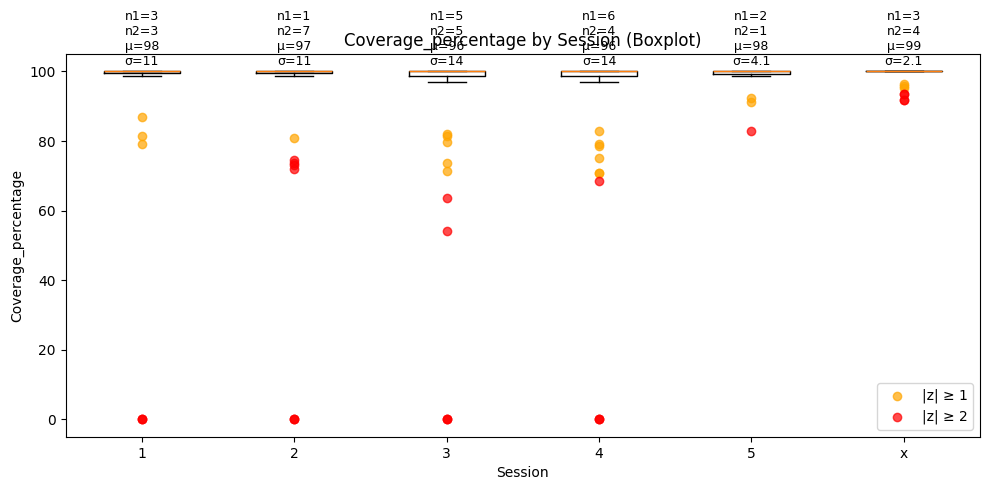

Union of outliers (|Coverage_percentage_zscore| >= 1): ['sub-RCX203_ses-1_task-BDM_run-1_bold', 'sub-RCX203_ses-1_task-BDM_run-2_bold', 'sub-RCX203_ses-1_task-BDM_run-3_bold', 'sub-RCX203_ses-2_task-BDM_run-1_bold', 'sub-RCX203_ses-2_task-BDM_run-2_bold', 'sub-RCX203_ses-2_task-BDM_run-3_bold', 'sub-RCX203_ses-3_task-BDM_run-1_bold', 'sub-RCX203_ses-3_task-BDM_run-2_bold', 'sub-RCX203_ses-3_task-BDM_run-3_bold', 'sub-RCX203_ses-4_task-BDM_run-1_bold', 'sub-RCX203_ses-4_task-BDM_run-2_bold', 'sub-RCX203_ses-4_task-BDM_run-3_bold', 'sub-RGC901_ses-x_task-BDM_run-1_bold', 'sub-RGC916_ses-1_task-BDM_run-2_bold', 'sub-RGC916_ses-x_task-BDM_run-1_bold', 'sub-RGC916_ses-x_task-BDM_run-2_bold', 'sub-RGC916_ses-x_task-BDM_run-3_bold', 'sub-RGC917_ses-x_task-BDM_run-1_bold', 'sub-RGC917_ses-x_task-BDM_run-2_bold', 'sub-RGC917_ses-x_task-BDM_run-3_bold', 'sub-RND001_ses-4_task-BDM_run-1_bold', 'sub-RND001_ses-4_task-BDM_run-3_bold', 'sub-RND002_ses-2_task-BDM_run-1_bold', 'sub-RND002_ses-2_task-B

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


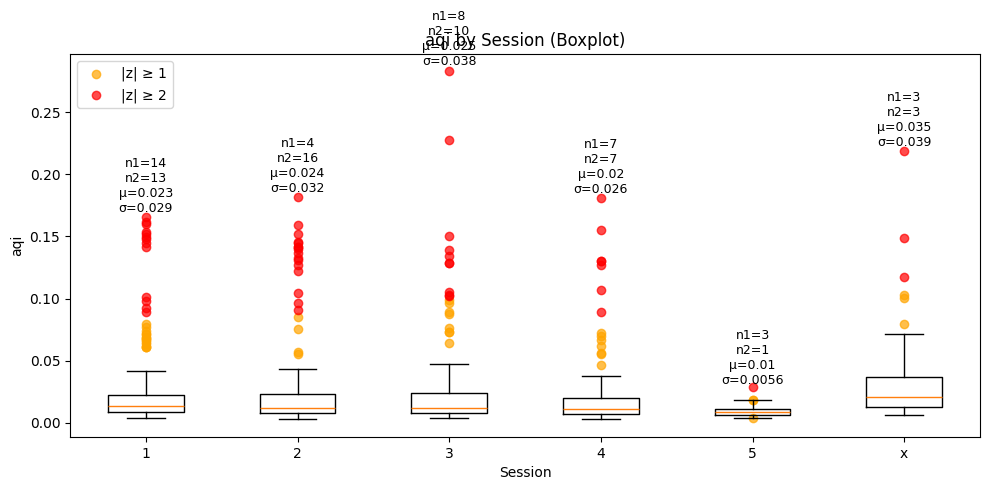

Union of outliers (|aqi_zscore| >= 1): ['sub-RCX096_ses-3_task-BDM_run-1_bold', 'sub-RCX096_ses-3_task-BDM_run-2_bold', 'sub-RCX146_ses-3_task-BDM_run-2_bold', 'sub-RCX147_ses-2_task-BDM_run-1_bold', 'sub-RCX164_ses-4_task-BDM_run-2_bold', 'sub-RCX191_ses-2_task-BDM_run-2_bold', 'sub-RCX200_ses-1_task-BDM_run-3_bold', 'sub-RCX219_ses-1_task-BDM_run-3_bold', 'sub-RCX219_ses-3_task-BDM_run-1_bold', 'sub-RGC902_ses-2_task-BDM_run-1_bold', 'sub-RGC903_ses-2_task-BDM_run-1_bold', 'sub-RGC904_ses-1_task-BDM_run-2_bold', 'sub-RGC904_ses-1_task-BDM_run-3_bold', 'sub-RGC904_ses-x_task-BDM_run-1_bold', 'sub-RGC904_ses-x_task-BDM_run-3_bold', 'sub-RGC907_ses-x_task-BDM_run-2_bold', 'sub-RGC910_ses-1_task-BDM_run-3_bold', 'sub-RGC912_ses-2_task-BDM_run-1_bold', 'sub-RGC913_ses-1_task-BDM_run-1_bold', 'sub-RGC913_ses-1_task-BDM_run-2_bold', 'sub-RGC913_ses-1_task-BDM_run-3_bold', 'sub-RGC916_ses-2_task-BDM_run-2_bold', 'sub-RGC916_ses-2_task-BDM_run-3_bold', 'sub-RGC916_ses-x_task-BDM_run-2_bold', 

C:\Users\Patrick\AppData\Local\Temp\ipykernel_13504\908609853.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


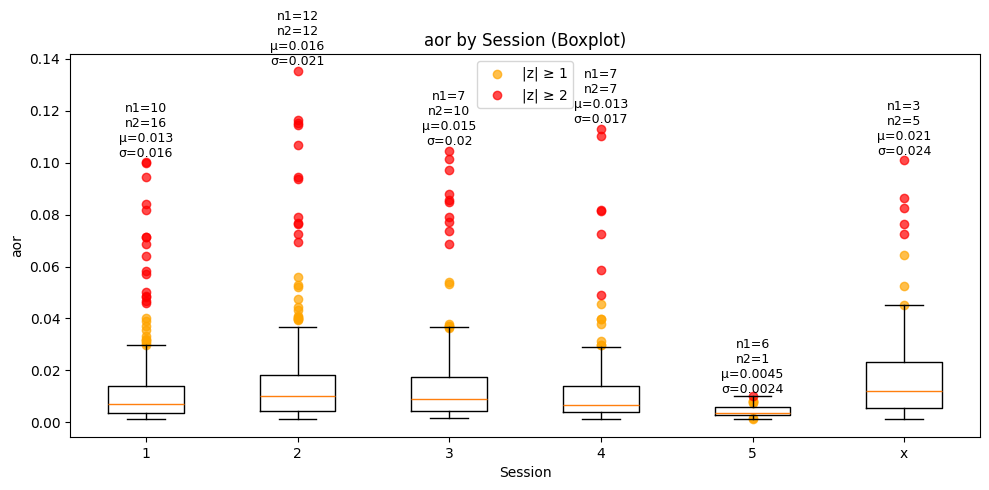

Union of outliers (|aor_zscore| >= 1): ['sub-RCX096_ses-3_task-BDM_run-1_bold', 'sub-RCX096_ses-3_task-BDM_run-2_bold', 'sub-RCX097_ses-4_task-BDM_run-3_bold', 'sub-RCX147_ses-2_task-BDM_run-1_bold', 'sub-RCX164_ses-4_task-BDM_run-2_bold', 'sub-RCX164_ses-4_task-BDM_run-3_bold', 'sub-RCX191_ses-2_task-BDM_run-2_bold', 'sub-RCX200_ses-1_task-BDM_run-3_bold', 'sub-RCX219_ses-3_task-BDM_run-1_bold', 'sub-RCX219_ses-3_task-BDM_run-2_bold', 'sub-RGC902_ses-2_task-BDM_run-1_bold', 'sub-RGC903_ses-2_task-BDM_run-1_bold', 'sub-RGC903_ses-x_task-BDM_run-2_bold', 'sub-RGC904_ses-1_task-BDM_run-2_bold', 'sub-RGC904_ses-1_task-BDM_run-3_bold', 'sub-RGC904_ses-x_task-BDM_run-1_bold', 'sub-RGC904_ses-x_task-BDM_run-2_bold', 'sub-RGC904_ses-x_task-BDM_run-3_bold', 'sub-RGC907_ses-x_task-BDM_run-2_bold', 'sub-RGC910_ses-1_task-BDM_run-2_bold', 'sub-RGC910_ses-1_task-BDM_run-3_bold', 'sub-RGC912_ses-2_task-BDM_run-1_bold', 'sub-RGC913_ses-1_task-BDM_run-1_bold', 'sub-RGC913_ses-1_task-BDM_run-2_bold', 

In [47]:
zscore_interest = [
    'tsnr_zscore',
    'fd_mean_zscore',
    'fd_num_above_3mm_zscore',
    'dummy_trs_zscore',
    'fd_max_zscore',
    'Coverage_percentage_zscore',
    'aqi_zscore',
    'aor_zscore'
]
orig_interest = [z[:-7] for z in zscore_interest]

for z_col, orig_col in zip(zscore_interest, orig_interest):
    plt.figure(figsize=(10, 5))
    data = []
    labels = []
    outlier1_x = []
    outlier1_y = []
    outlier2_x = []
    outlier2_y = []
    for i, (session, group) in enumerate(df_mriqc.groupby('Session')):
        data.append(group[orig_col].dropna())
        labels.append(session)
        # Outliers for |z| >= 2
        mask2 = (group[z_col] <= -2) | (group[z_col] >= 2)
        outlier2_x.extend([i + 1] * mask2.sum())
        outlier2_y.extend(group.loc[mask2, orig_col])
        # Outliers for |z| >= 1 and < 2
        mask1 = ((group[z_col] <= -1) | (group[z_col] >= 1)) & ~mask2
        outlier1_x.extend([i + 1] * mask1.sum())
        outlier1_y.extend(group.loc[mask1, orig_col])
        # Add annotation for number of outliers per session per criteria
        n_out1 = mask1.sum()
        n_out2 = mask2.sum()
        mean_val = group[orig_col].mean()
        std_val = group[orig_col].std()
        # Place annotation above the box
        plt.text(i + 1, group[orig_col].max() + 0.01 * abs(group[orig_col].max()), 
             f"n1={n_out1}\nn2={n_out2}\nμ={mean_val:.2g}\nσ={std_val:.2g}", 
             ha='center', va='bottom', fontsize=9, color='black')
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.scatter(outlier1_x, outlier1_y, color='orange', label='|z| ≥ 1', alpha=0.7)
    plt.scatter(outlier2_x, outlier2_y, color='red', label='|z| ≥ 2', alpha=0.7)
    plt.title(f"{orig_col} by Session (Boxplot)")
    plt.xlabel('Session')
    plt.ylabel(orig_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Find union of outliers for |z| >= 1 and |z| >= 2 for the current z-score column
    outliers_z1 = df_mriqc.loc[(df_mriqc[z_col] <= -1) | (df_mriqc[z_col] >= 1), 'bids_name']
    outliers_z2 = df_mriqc.loc[(df_mriqc[z_col] <= -2) | (df_mriqc[z_col] >= 2), 'bids_name']

    print(f"Union of outliers (|{z_col}| >= 1): {sorted(outliers_z1.unique())}")
    print(f"Union of outliers (|{z_col}| >= 2): {sorted(outliers_z2.unique())}")

    # Save outlier lists to a text file in the same directory as df_mriqc
    outlier_file = '/home/gagpat01/mes_projets/maitrise/fmri/results/outlier_bids_names.txt'
    with open(outlier_file, 'a') as f:
        f.write(f"\n==== {z_col} ====\n")
        f.write(f"Union of outliers (|{z_col}| >= 1):\n")
        for name in sorted(outliers_z1.unique()):
            f.write(f"{name}\n")
        f.write(f"\nUnion of outliers (|{z_col}| >= 2):\n")
        for name in sorted(outliers_z2.unique()):
            f.write(f"{name}\n")

In [48]:
# Build a list of runs to exclude based on stringent criteria
stringent = df_mriqc[
    (df_mriqc['tsnr_zscore'] < -1) |
    (df_mriqc['fd_max'] > 3) |
    (df_mriqc['fd_mean_zscore'] > 1) |
    (df_mriqc['aqi_zscore'] > 1) |
    (df_mriqc['aor_zscore'] > 1) |
    (df_mriqc['Coverage_percentage'] < 90) |
    (df_mriqc['dummy_trs'] > 0)
]['bids_name'].unique().tolist()

print(f"Number of stringent exclusions: {len(stringent)}")
print("Stringent exclusion list (first 20):", stringent[:20])

# Report per-criterion counts for stringent
criteria_stringent = {
    'tsnr_zscore < -1': (df_mriqc['tsnr_zscore'] < -1),
    'fd_max > 3': (df_mriqc['fd_max'] > 3),
    'fd_mean_zscore > 1': (df_mriqc['fd_mean_zscore'] > 1),
    'aqi_zscore > 1': (df_mriqc['aqi_zscore'] > 1),
    'aor_zscore > 1': (df_mriqc['aor_zscore'] > 1),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90),
    'dummy_trs > 0': (df_mriqc['dummy_trs'] > 0)
}
for label, mask in criteria_stringent.items():
    count = df_mriqc.loc[mask, 'bids_name'].nunique()
    print(f"Stringent: {label}: {count}")

# Build a list of runs to exclude based on less severe criteria
less_severe = df_mriqc[
    (df_mriqc['tsnr_zscore'] < -2) |
    (df_mriqc['fd_num_above_3mm_zscore'] > 1) |
    (df_mriqc['fd_mean_zscore'] > 2) |
    (df_mriqc['aqi_zscore'] > 2) |
    (df_mriqc['aor_zscore'] > 2) |
    (df_mriqc['Coverage_percentage'] < 90)
]['bids_name'].unique().tolist()

print(f"Number of less severe exclusions: {len(less_severe)}")
print("Less severe exclusion list (first 20):", less_severe[:20])

# Report per-criterion counts for less severe
criteria_less_severe = {
    'tsnr_zscore < -2': (df_mriqc['tsnr_zscore'] < -2),
    'fd_num_above_3mm_zscore > 1': (df_mriqc['fd_num_above_3mm_zscore'] > 1),
    'fd_mean_zscore > 2': (df_mriqc['fd_mean_zscore'] > 2),
    'aqi_zscore > 2': (df_mriqc['aqi_zscore'] > 2),
    'aor_zscore > 2': (df_mriqc['aor_zscore'] > 2),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90)
}
for label, mask in criteria_less_severe.items():
    count = df_mriqc.loc[mask, 'bids_name'].nunique()
    print(f"Less severe: {label}: {count}")

# Build a list of runs to exclude if fd_max > 3 or any less severe criteria are met
fdmax_or_less_severe = df_mriqc[
    (df_mriqc['fd_max'] > 3) |
    (df_mriqc['tsnr_zscore'] < -2) |
    (df_mriqc['fd_num_above_3mm_zscore'] > 1) |
    (df_mriqc['fd_mean_zscore'] > 2) |
    (df_mriqc['aqi_zscore'] > 2) |
    (df_mriqc['aor_zscore'] > 2) |
    (df_mriqc['Coverage_percentage'] < 90)
]['bids_name'].unique().tolist()

print(f"Number of fd_max or less severe exclusions: {len(fdmax_or_less_severe)}")
print("fd_max or less severe exclusion list (first 20):", fdmax_or_less_severe[:20])

# Report per-criterion counts for fd_max or less severe
criteria_fdmax_or_less_severe = {
    'fd_max > 3': (df_mriqc['fd_max'] > 3),
    'tsnr_zscore < -2': (df_mriqc['tsnr_zscore'] < -2),
    'fd_num_above_3mm_zscore > 1': (df_mriqc['fd_num_above_3mm_zscore'] > 1),
    'fd_mean_zscore > 2': (df_mriqc['fd_mean_zscore'] > 2),
    'aqi_zscore > 2': (df_mriqc['aqi_zscore'] > 2),
    'aor_zscore > 2': (df_mriqc['aor_zscore'] > 2),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90)
}
for label, mask in criteria_fdmax_or_less_severe.items():
    count = df_mriqc.loc[mask, 'bids_name'].nunique()
    print(f"fd_max or less severe: {label}: {count}")

Number of stringent exclusions: 389
Stringent exclusion list (first 20): ['sub-RCX096_ses-3_task-BDM_run-1_bold', 'sub-RCX096_ses-3_task-BDM_run-2_bold', 'sub-RCX096_ses-4_task-BDM_run-2_bold', 'sub-RCX097_ses-1_task-BDM_run-1_bold', 'sub-RCX097_ses-1_task-BDM_run-3_bold', 'sub-RCX097_ses-3_task-BDM_run-3_bold', 'sub-RCX097_ses-4_task-BDM_run-2_bold', 'sub-RCX097_ses-4_task-BDM_run-3_bold', 'sub-RCX126_ses-1_task-BDM_run-3_bold', 'sub-RCX126_ses-2_task-BDM_run-3_bold', 'sub-RCX126_ses-3_task-BDM_run-2_bold', 'sub-RCX126_ses-3_task-BDM_run-3_bold', 'sub-RCX126_ses-4_task-BDM_run-2_bold', 'sub-RCX136_ses-2_task-BDM_run-3_bold', 'sub-RCX136_ses-3_task-BDM_run-2_bold', 'sub-RCX136_ses-3_task-BDM_run-3_bold', 'sub-RCX146_ses-1_task-BDM_run-3_bold', 'sub-RCX146_ses-2_task-BDM_run-1_bold', 'sub-RCX146_ses-3_task-BDM_run-1_bold', 'sub-RCX146_ses-3_task-BDM_run-2_bold']
Stringent: tsnr_zscore < -1: 167
Stringent: fd_max > 3: 228
Stringent: fd_mean_zscore > 1: 95
Stringent: aqi_zscore > 1: 88
St

In [49]:
# Save the merged DataFrame
df_mriqc.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/group_bold_with_coverage.tsv', sep='\t', index=False)

# Helper to get valid participants - NOW INCLUDES RGC, single-session, and missing-first-session participants
def get_valid_participants(df, exclusion_list):
    # Exclude runs in exclusion_list
    remaining = df[~df['bids_name'].isin(exclusion_list)].copy()
    # Extract participant and session
    remaining['participant'] = remaining['bids_name'].str.extract(r'(sub-[^_]+)')[0]
    remaining['session'] = remaining['bids_name'].str.extract(r'ses-([a-zA-Z0-9]+)')[0]
    # NO LONGER filtering out RGC, single-session, or missing-first-session participants
    # Simply return unique participant count
    return remaining['participant'].nunique()

n_total = get_valid_participants(df_mriqc, [])
print(f"Total valid participants: {n_total}")

n_stringent = get_valid_participants(df_mriqc, stringent)
print(f"Valid participants left after stringent exclusion: {n_stringent}")

n_less_severe = get_valid_participants(df_mriqc, less_severe)
print(f"Valid participants left after less severe exclusion: {n_less_severe}")

n_fdmax_or_less_severe = get_valid_participants(df_mriqc, fdmax_or_less_severe)
print(f"Valid participants left after fd_max or less severe exclusion: {n_fdmax_or_less_severe}")

Total valid participants: 98
Valid participants left after stringent exclusion: 90
Valid participants left after less severe exclusion: 95
Valid participants left after fd_max or less severe exclusion: 94


In [50]:
# Compute and print the average number of runs per session for each exclusion criteria
# NOW INCLUDES RGC, single-session, and missing-first-session participants
def avg_runs_per_session(df, exclusion_list):
    filtered = df[~df['bids_name'].isin(exclusion_list)].copy()
    filtered['participant'] = filtered['bids_name'].str.extract(r'(sub-[^_]+)')[0]
    filtered['session'] = filtered['bids_name'].str.extract(r'ses-([a-zA-Z0-9]+)')[0]
    # NO LONGER filtering out RGC, single-session, or missing-first-session participants
    # Now compute average runs per session for ALL participants
    runs_per_session = filtered.groupby(['participant', 'session']).size()
    return runs_per_session.mean()

avg_total = avg_runs_per_session(df_mriqc, [])
print(f"Average runs per session (no exclusion): {avg_total:.2f}")

avg_stringent = avg_runs_per_session(df_mriqc, stringent)
print(f"Average runs per session (stringent exclusion): {avg_stringent:.2f}")

avg_less_severe = avg_runs_per_session(df_mriqc, less_severe)
print(f"Average runs per session (less severe exclusion): {avg_less_severe:.2f}")

avg_fdmax_or_less_severe = avg_runs_per_session(df_mriqc, fdmax_or_less_severe)
print(f"Average runs per session (fd_max or less severe exclusion): {avg_fdmax_or_less_severe:.2f}")

Average runs per session (no exclusion): 2.98
Average runs per session (stringent exclusion): 2.22
Average runs per session (less severe exclusion): 2.73
Average runs per session (fd_max or less severe exclusion): 2.54


In [51]:
# Save exclusion lists as TSV files with exclusion criteria
# Participant-level issues (RGC, single-session, missing first session) are added as criteria flags, not blanket exclusions

import numpy as np

def get_exclusion_criteria_df_with_participant(df, criteria_dict, exclusion_list, participants_rgc, participants_one_session, participants_missing_first):
    # For each run, collect all criteria that apply
    criteria_cols = []
    for label, mask in criteria_dict.items():
        col = f"crit_{label.replace(' ', '_').replace('<', 'lt').replace('>', 'gt').replace('=', 'eq')}"
        df[col] = mask
        criteria_cols.append((col, label))
    # Only keep runs in exclusion_list
    excl_df = df[df['bids_name'].isin(exclusion_list)].copy()
    # For each run, list all criteria that are True
    def collect_criteria(row):
        criteria_list = [label for col, label in criteria_cols if row[col]]
        # Add participant-level flags if applicable
        if row['participant'] in participants_rgc:
            criteria_list.append('RGC_participant')
        if row['participant'] in participants_one_session:
            criteria_list.append('only_one_session')
        if row['participant'] in participants_missing_first:
            criteria_list.append('missing_first_session')
        return ";".join(criteria_list) if criteria_list else "No IQM failure (participant-level flag only)"
    excl_df['criteria'] = excl_df.apply(collect_criteria, axis=1)
    return excl_df[['bids_name', 'participant', 'session', 'criteria']]

# Add participant/session columns to df_mriqc for filtering
if 'participant' not in df_mriqc.columns:
    df_mriqc['participant'] = df_mriqc['bids_name'].str.extract(r'(sub-[^_]+)')[0]
if 'session' not in df_mriqc.columns:
    df_mriqc['session'] = df_mriqc['bids_name'].str.extract(r'ses-([a-zA-Z0-9]+)')[0]

# Identify participants with participant-level issues (for flagging, not exclusion)
session_counts = df_mriqc.groupby('participant')['session'].nunique()
participants_one_session = set(session_counts[session_counts == 1].index)
session_map = df_mriqc.groupby('participant')['session'].unique()
def has_first_session(sessions):
    return ('1' in sessions) or ('01' in sessions)
participants_missing_first = set([p for p, s in session_map.items() if not has_first_session(s)])
participants_rgc = set([p for p in df_mriqc['participant'].unique() if 'RGC' in p])

# Prepare criteria dicts - IQM criteria apply to ALL participants
criteria_stringent = {
    'tsnr_zscore < -1': (df_mriqc['tsnr_zscore'] < -1),
    'fd_max > 3': (df_mriqc['fd_max'] > 3),
    'fd_mean_zscore > 1': (df_mriqc['fd_mean_zscore'] > 1),
    'aqi_zscore > 1': (df_mriqc['aqi_zscore'] > 1),
    'aor_zscore > 1': (df_mriqc['aor_zscore'] > 1),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90),
    'dummy_trs > 0': (df_mriqc['dummy_trs'] > 0)
}
criteria_less_severe = {
    'tsnr_zscore < -2': (df_mriqc['tsnr_zscore'] < -2),
    'fd_num_above_3mm_zscore > 1': (df_mriqc['fd_num_above_3mm_zscore'] > 1),
    'fd_mean_zscore > 2': (df_mriqc['fd_mean_zscore'] > 2),
    'aqi_zscore > 2': (df_mriqc['aqi_zscore'] > 2),
    'aor_zscore > 2': (df_mriqc['aor_zscore'] > 2),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90)
}
criteria_fdmax_or_less_severe = {
    'fd_max > 3': (df_mriqc['fd_max'] > 3),
    'tsnr_zscore < -2': (df_mriqc['tsnr_zscore'] < -2),
    'fd_num_above_3mm_zscore > 1': (df_mriqc['fd_num_above_3mm_zscore'] > 1),
    'fd_mean_zscore > 2': (df_mriqc['fd_mean_zscore'] > 2),
    'aqi_zscore > 2': (df_mriqc['aqi_zscore'] > 2),
    'aor_zscore > 2': (df_mriqc['aor_zscore'] > 2),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90)
}

# Build exclusion DataFrames - all participants evaluated by IQM criteria
stringent_final = get_exclusion_criteria_df_with_participant(df_mriqc, criteria_stringent, stringent, 
                                                               participants_rgc, participants_one_session, participants_missing_first)
less_severe_final = get_exclusion_criteria_df_with_participant(df_mriqc, criteria_less_severe, less_severe,
                                                                 participants_rgc, participants_one_session, participants_missing_first)
fdmax_or_less_severe_final = get_exclusion_criteria_df_with_participant(df_mriqc, criteria_fdmax_or_less_severe, fdmax_or_less_severe,
                                                                          participants_rgc, participants_one_session, participants_missing_first)

# Save as TSV
stringent_final.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/stringent_exclusion_bids_names.tsv', sep='\t', index=False)
less_severe_final.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/less_severe_exclusion_bids_names.tsv', sep='\t', index=False)
fdmax_or_less_severe_final.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/fdmax_or_less_severe_exclusion_bids_names.tsv', sep='\t', index=False)

print("Exclusion lists saved as TSV with IQM criteria and participant-level flags.")
print(f"Stringent exclusions: {len(stringent_final)}")
print(f"Less severe exclusions: {len(less_severe_final)}")
print(f"FDmax or less severe exclusions: {len(fdmax_or_less_severe_final)}")

# Report how many exclusions have participant-level flags
for name, df_out in [('Stringent', stringent_final), ('Less severe', less_severe_final), ('FDmax or less severe', fdmax_or_less_severe_final)]:
    rgc_count = df_out[df_out['criteria'].str.contains('RGC_participant', na=False)].shape[0]
    one_session_count = df_out[df_out['criteria'].str.contains('only_one_session', na=False)].shape[0]
    missing_first_count = df_out[df_out['criteria'].str.contains('missing_first_session', na=False)].shape[0]
    print(f"{name}: RGC={rgc_count}, one_session={one_session_count}, missing_first={missing_first_count}")

Exclusion lists saved as TSV with IQM criteria and participant-level flags.
Stringent exclusions: 389
Less severe exclusions: 142
FDmax or less severe exclusions: 270
Stringent: RGC=71, one_session=11, missing_first=25
Less severe: RGC=27, one_session=4, missing_first=21
FDmax or less severe: RGC=62, one_session=7, missing_first=21


In [52]:
# Save exclusion lists as TSV files with exclusion criteria
# Participant-level issues (RGC, single-session, missing first session) are added as criteria flags
# Only runs that FAIL IQM criteria are included in the exclusion lists

import numpy as np

def get_exclusion_criteria_df_with_participant(df, criteria_dict, exclusion_list, participants_rgc, participants_one_session, participants_missing_first):
    # For each run, collect all criteria that apply
    criteria_cols = []
    for label, mask in criteria_dict.items():
        col = f"crit_{label.replace(' ', '_').replace('<', 'lt').replace('>', 'gt').replace('=', 'eq')}"
        df[col] = mask
        criteria_cols.append((col, label))
    # Only keep runs in exclusion_list (runs that FAILED IQM criteria)
    excl_df = df[df['bids_name'].isin(exclusion_list)].copy()
    # For each run, list all criteria that are True
    def collect_criteria(row):
        criteria_list = [label for col, label in criteria_cols if row[col]]
        # Add participant-level flags if applicable
        if row['participant'] in participants_rgc:
            criteria_list.append('RGC_participant')
        if row['participant'] in participants_one_session:
            criteria_list.append('only_one_session')
        if row['participant'] in participants_missing_first:
            criteria_list.append('missing_first_session')
        return ";".join(criteria_list)
    excl_df['criteria'] = excl_df.apply(collect_criteria, axis=1)
    # Drop temporary criteria columns
    excl_df = excl_df.drop(columns=[col for col, _ in criteria_cols])
    return excl_df[['bids_name', 'participant', 'session', 'criteria']]

# Add participant/session columns to df_mriqc for filtering
if 'participant' not in df_mriqc.columns:
    df_mriqc['participant'] = df_mriqc['bids_name'].str.extract(r'(sub-[^_]+)')[0]
if 'session' not in df_mriqc.columns:
    df_mriqc['session'] = df_mriqc['bids_name'].str.extract(r'ses-([a-zA-Z0-9]+)')[0]

# Identify participants with participant-level issues (for flagging only, NOT for exclusion)
session_counts = df_mriqc.groupby('participant')['session'].nunique()
participants_one_session = set(session_counts[session_counts == 1].index)
session_map = df_mriqc.groupby('participant')['session'].unique()
def has_first_session(sessions):
    return ('1' in sessions) or ('01' in sessions)
participants_missing_first = set([p for p, s in session_map.items() if not has_first_session(s)])
participants_rgc = set([p for p in df_mriqc['participant'].unique() if 'RGC' in p])

# Prepare criteria dicts - IQM criteria apply to ALL participants
criteria_stringent = {
    'tsnr_zscore < -1': (df_mriqc['tsnr_zscore'] < -1),
    'fd_max > 3': (df_mriqc['fd_max'] > 3),
    'fd_mean_zscore > 1': (df_mriqc['fd_mean_zscore'] > 1),
    'aqi_zscore > 1': (df_mriqc['aqi_zscore'] > 1),
    'aor_zscore > 1': (df_mriqc['aor_zscore'] > 1),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90),
    'dummy_trs > 0': (df_mriqc['dummy_trs'] > 0)
}
criteria_less_severe = {
    'tsnr_zscore < -2': (df_mriqc['tsnr_zscore'] < -2),
    'fd_num_above_3mm_zscore > 1': (df_mriqc['fd_num_above_3mm_zscore'] > 1),
    'fd_mean_zscore > 2': (df_mriqc['fd_mean_zscore'] > 2),
    'aqi_zscore > 2': (df_mriqc['aqi_zscore'] > 2),
    'aor_zscore > 2': (df_mriqc['aor_zscore'] > 2),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90)
}
criteria_fdmax_or_less_severe = {
    'fd_max > 3': (df_mriqc['fd_max'] > 3),
    'tsnr_zscore < -2': (df_mriqc['tsnr_zscore'] < -2),
    'fd_num_above_3mm_zscore > 1': (df_mriqc['fd_num_above_3mm_zscore'] > 1),
    'fd_mean_zscore > 2': (df_mriqc['fd_mean_zscore'] > 2),
    'aqi_zscore > 2': (df_mriqc['aqi_zscore'] > 2),
    'aor_zscore > 2': (df_mriqc['aor_zscore'] > 2),
    'Coverage_percentage < 90': (df_mriqc['Coverage_percentage'] < 90)
}

# Build exclusion DataFrames - only runs that FAILED IQM criteria, with participant flags added
stringent_final = get_exclusion_criteria_df_with_participant(df_mriqc, criteria_stringent, stringent, 
                                                               participants_rgc, participants_one_session, participants_missing_first)
less_severe_final = get_exclusion_criteria_df_with_participant(df_mriqc, criteria_less_severe, less_severe,
                                                                 participants_rgc, participants_one_session, participants_missing_first)
fdmax_or_less_severe_final = get_exclusion_criteria_df_with_participant(df_mriqc, criteria_fdmax_or_less_severe, fdmax_or_less_severe,
                                                                          participants_rgc, participants_one_session, participants_missing_first)

# Save as TSV
stringent_final.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/stringent_exclusion_bids_names.tsv', sep='\t', index=False)
less_severe_final.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/less_severe_exclusion_bids_names.tsv', sep='\t', index=False)
fdmax_or_less_severe_final.to_csv('/home/gagpat01/mes_projets/maitrise/fmri/results/fdmax_or_less_severe_exclusion_bids_names.tsv', sep='\t', index=False)

print("Exclusion lists saved as TSV with IQM criteria and participant-level flags.")
print(f"Stringent exclusions: {len(stringent_final)}")
print(f"Less severe exclusions: {len(less_severe_final)}")
print(f"FDmax or less severe exclusions: {len(fdmax_or_less_severe_final)}")

# Report how many exclusions have participant-level flags
for name, df_out in [('Stringent', stringent_final), ('Less severe', less_severe_final), ('FDmax or less severe', fdmax_or_less_severe_final)]:
    rgc_count = df_out[df_out['criteria'].str.contains('RGC_participant', na=False)].shape[0]
    one_session_count = df_out[df_out['criteria'].str.contains('only_one_session', na=False)].shape[0]
    missing_first_count = df_out[df_out['criteria'].str.contains('missing_first_session', na=False)].shape[0]
    print(f"{name}: RGC={rgc_count}, one_session={one_session_count}, missing_first={missing_first_count}")

Exclusion lists saved as TSV with IQM criteria and participant-level flags.
Stringent exclusions: 389
Less severe exclusions: 142
FDmax or less severe exclusions: 270
Stringent: RGC=71, one_session=11, missing_first=25
Less severe: RGC=27, one_session=4, missing_first=21
FDmax or less severe: RGC=62, one_session=7, missing_first=21


In [53]:
# Print included bids_name for each exclusion list (i.e., those NOT excluded), applying participant-level exclusions

# Print included bids_name for each exclusion list (i.e., those NOT excluded)
# NOW INCLUDES RGC, single-session, and missing-first-session participants
def get_included_bids_names(df, exclusion_list):
    included = df[~df['bids_name'].isin(exclusion_list)].copy()
    included['participant'] = included['bids_name'].str.extract(r'(sub-[^_]+)')[0]
    included['session'] = included['bids_name'].str.extract(r'ses-([a-zA-Z0-9]+)')[0]
    # NO LONGER filtering out RGC, single-session, or missing-first-session participants
    # Simply return all included bids_names
    return included['bids_name'].tolist()

included_stringent = get_included_bids_names(df_mriqc, stringent)
included_less_severe = get_included_bids_names(df_mriqc, less_severe)
included_fdmax_or_less_severe = get_included_bids_names(df_mriqc, fdmax_or_less_severe)

print("Included bids_name (stringent):", included_stringent)
print("Included bids_name (less severe):", included_less_severe)
print("Included bids_name (fd_max or less severe):", included_fdmax_or_less_severe)

included_files = {
    'stringent': '/home/gagpat01/mes_projets/maitrise/fmri/results/included_stringent_bids_names.txt',
    'less_severe': '/home/gagpat01/mes_projets/maitrise/fmri/results/included_less_severe_bids_names.txt',
    'fdmax_or_less_severe': '/home/gagpat01/mes_projets/maitrise/fmri/results/included_fdmax_or_less_severe_bids_names.txt'
}

included_lists = {
    'stringent': included_stringent,
    'less_severe': included_less_severe,
    'fdmax_or_less_severe': included_fdmax_or_less_severe
}

for key in included_files:
    with open(included_files[key], 'w') as f:
        for name in included_lists[key]:
            f.write(f"{name}\n")
    print(f"Included bids_name ({key}) saved to {included_files[key]}")

Included bids_name (stringent): ['sub-RCX096_ses-2_task-BDM_run-1_bold', 'sub-RCX096_ses-2_task-BDM_run-2_bold', 'sub-RCX096_ses-2_task-BDM_run-3_bold', 'sub-RCX096_ses-3_task-BDM_run-3_bold', 'sub-RCX096_ses-4_task-BDM_run-1_bold', 'sub-RCX096_ses-4_task-BDM_run-3_bold', 'sub-RCX097_ses-1_task-BDM_run-2_bold', 'sub-RCX097_ses-2_task-BDM_run-1_bold', 'sub-RCX097_ses-2_task-BDM_run-2_bold', 'sub-RCX097_ses-2_task-BDM_run-3_bold', 'sub-RCX097_ses-3_task-BDM_run-1_bold', 'sub-RCX097_ses-3_task-BDM_run-2_bold', 'sub-RCX097_ses-4_task-BDM_run-1_bold', 'sub-RCX126_ses-1_task-BDM_run-1_bold', 'sub-RCX126_ses-1_task-BDM_run-2_bold', 'sub-RCX126_ses-2_task-BDM_run-1_bold', 'sub-RCX126_ses-2_task-BDM_run-2_bold', 'sub-RCX126_ses-3_task-BDM_run-1_bold', 'sub-RCX126_ses-4_task-BDM_run-1_bold', 'sub-RCX126_ses-4_task-BDM_run-3_bold', 'sub-RCX136_ses-1_task-BDM_run-1_bold', 'sub-RCX136_ses-1_task-BDM_run-2_bold', 'sub-RCX136_ses-1_task-BDM_run-3_bold', 'sub-RCX136_ses-2_task-BDM_run-1_bold', 'sub-RC